# Etapa 1: Preparação dos dados e protocolo de avaliação

Nesta etapa definimos os conjuntos e o pré-processamento, sem ajustar transformadores ou treinar modelos.

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1.1 Carregamento

O CSV está em `data/dados.csv`. O caminho abaixo funciona com o kernel iniciado na raiz do projeto ou na pasta `notebooks`. Nenhuma estatística é aprendida nesta leitura.

In [ ]:
data_path = Path("data/dados.csv")
if not data_path.is_file():
    data_path = Path("../data/dados.csv")
if not data_path.is_file():
    raise FileNotFoundError("Execute a partir da raiz do projeto ou de notebooks: data/dados.csv não encontrado.")

df_raw = pd.read_csv(data_path)

#Legenda para as colunas:

* 'Age': Idade do funcionário.

* 'Attrition': Desligamento (Indica se o funcionário saiu alguma vez da empresa)

* 'BusinessTravel': Indica a frequência com que o funcionário viaja a travalho

* 'DailyRate': Valor do salário por dia.

* 'Department': Departamento no qual o funcionário trabalha.

* 'DistanceFromHome': Distância em km/milhas da casa ao trabalho.

* 'Education': Nível de escolaridade

* 'EducationField': Área de formação.

* 'EmployeeCount': Coluna constante nos valores observados do projeto original (1), com ausências. Será removida; não deve ser preenchida usando Attrition.

* 'EmployeeNumber': Número de identificação do funcionário; será removido das features.

* 'EnvironmentSatisfaction': Satisfação com o ambiente de trabalho.

* 'Gender': Gênero do funcionário.

* 'HourlyRate': Valor do salário por hora. Observações: Verificar se é proprocional ou não a coluna 'DailyRate' (Valor do salário por dia). Caso haja algum tipo de proporção, basta excluir uma das colunas (informação redundante).

* 'JobInvolvement': Nível de engajamento com as tarefas.

* 'JobLevel': Nível do cargo.

* 'JobRole': Cargo/Função (Descrição do cargo)

* 'JobSatisfaction': Satisfação com o Trabalho (Nível de satisfação geral com o cargo).

* 'MaritalStatus': Estado Civil (Solteiro, Casado, Divorciado).

* 'MonthlyIncome': Renda Mensal (Salário bruto mensal).

* 'MonthlyRate': Valor/Taxa Mensal (Uma taxa interna da empresa, não é o salário).

* 'NumCompaniesWorked': Número de Empresas Anteriores (Quantas empresas o funcionário trabalhou antes desta).

* 'Over18': Acima de 18 Anos (Indica se o funcionário é maior de idade).

* 'OverTime': Horas Extras (Indica se o funcionário faz horas extras - Sim/Não).

* 'PercentSalaryHike': Aumento Percentual do Salário (Percentual do último aumento salarial).

* 'PerformanceRating': Avaliação de Desempenho (Nota da última avaliação de performance).

* 'RelationshipSatisfaction': Satisfação com Relacionamentos (Nível de satisfação com colegas e gestores).

* 'StandardHours': Horas Padrão (A carga horária padrão de trabalho, ex: 80 horas).

* 'StockOptionLevel': Nível de Opção de Ações (Nível do benefício de compra de ações da empresa).

* 'TotalWorkingYears': Total de Anos Trabalhados (Tempo total de experiência de carreira).

* 'TrainingTimesLastYear': Treinamentos no Último Ano (Número de treinamentos que participou no ano anterior).

* 'WorkLifeBalance': Equilíbrio Vida-Trabalho (Nível de satisfação com o equilíbrio entre vida pessoal e profissional).

* 'YearsAtCompany': Anos na Empresa (Tempo total de casa).

* 'YearsInCurrentRole': Anos no Cargo Atual (Tempo que está na função atual).

* 'YearsSinceLastPromotion': Anos Desde a Última Promoção.

* 'YearsWithCurrManager': Anos com o Gestor Atual.

## 1.2 Remoção de colunas previamente justificadas

Preservamos a decisão documentada no projeto original: remover `StandardHours` (80), `Over18` (Y), `EmployeeCount` (1 nos valores observados) e `EmployeeNumber` (identificador). A lista é fixa; não fazemos nova seleção de features usando a base completa.

In [ ]:
columns_to_drop = ["StandardHours", "Over18", "EmployeeCount", "EmployeeNumber"]
df_features = df_raw.drop(columns=columns_to_drop)

## 1.3 Features e alvo

`X` contém apenas as features; `y` representa `Attrition`, com `No = 0` e `Yes = 1`. Validamos ausências e rótulos inesperados antes da conversão. Valores já codificados em 0/1 também são aceitos, sem modificar o alvo original.

In [ ]:
X = df_features.drop(columns="Attrition").copy()
target = df_features["Attrition"]
if target.isna().any() or not target.isin(["No", "Yes", 0, 1]).all():
    raise ValueError("Attrition deve conter apenas No/Yes ou 0/1, sem valores ausentes.")
y = target.map({"No": 0, "Yes": 1, 0: 0, 1: 1}).astype("int64")

## 1.4 Separação imediata entre treino e teste

**Data leakage** ocorre quando informações indisponíveis ao treinamento, como as do teste, influenciam a preparação ou a escolha do modelo. Por isso, separamos os dados antes de aprender medianas, modas ou parâmetros de escala.

`stratify=y` preserva aproximadamente a proporção das classes em cada conjunto. O teste ficará reservado até a avaliação final, sem orientar análises exploratórias, imputação, hiperparâmetros ou limiares. Esta divisão organiza a V2; não torna a base inédita, pois ela já foi explorada no projeto original.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Inspeção inicial da base de treinamento

Recuperamos somente as linhas de treino em `df_raw`, pelos índices de `X_train`, para inspecionar também as colunas já removidas das features. Esta cópia é exclusivamente descritiva: não modifica `X_train`, não usa o teste e mantém as ausências.

In [ ]:
df_train_raw = df_raw.loc[X_train.index].copy()
df_train_raw.info()
df_train_raw.head()

### Verificação das colunas removidas no treino

Confirmamos que `StandardHours`, `Over18` e `EmployeeCount` têm um único valor observado, desconsiderando ausências. Verificamos também a completude e a unicidade de `EmployeeNumber`, removido por ser identificador. A decisão de excluir as quatro colunas das features permanece; não preenchemos valores ausentes.

In [ ]:
constant_columns = ["StandardHours", "Over18", "EmployeeCount"]
for column in constant_columns:
    observed_values = df_train_raw[column].dropna().unique()
    print(f"{column}: valores observados = {observed_values}")
    assert len(observed_values) == 1, f"{column} não é constante nos valores observados do treino."

assert df_train_raw["EmployeeNumber"].notna().all(), "Há identificadores ausentes no treino."
assert df_train_raw["EmployeeNumber"].is_unique, "Há identificadores repetidos no treino."

removed_columns_audit = pd.DataFrame({
    "Valores distintos observados": df_train_raw[columns_to_drop].nunique(dropna=True),
    "Valores ausentes": df_train_raw[columns_to_drop].isna().sum(),
})
removed_columns_audit

### Correlação entre MonthlyRate, HourlyRate e DailyRate no treino

Retomamos a hipótese exploratória de que essas taxas poderiam conter informação linear redundante. A matriz de Pearson e o heatmap usam somente `X_train`, com pares de valores disponíveis: não há imputação nem exclusão global de linhas.

In [ ]:
rate_columns = ["MonthlyRate", "HourlyRate", "DailyRate"]
rate_correlation = X_train[rate_columns].corr(method="pearson")
print(rate_correlation.round(6))

fig_rates, ax_rates = plt.subplots(figsize=(6, 4))
sns.heatmap(
    rate_correlation, annot=True, cmap="coolwarm", fmt=".3f",
    vmin=-1, vmax=1, center=0, ax=ax_rates,
)
ax_rates.set_title("Correlação entre taxas — somente treino")
fig_rates.tight_layout()
plt.show()

Nesta divisão de treinamento, as correlações de Pearson são aproximadamente **0,0002** (MonthlyRate × HourlyRate), **−0,0508** (MonthlyRate × DailyRate) e **0,0238** (HourlyRate × DailyRate). Os valores próximos de zero não sustentam a hipótese de forte redundância linear entre essas taxas; portanto, mantemos as três features. Isso não demonstra ausência de relações não lineares nem garante valor preditivo.

## 1.5 Tipos de features no treinamento

Identificamos as colunas somente em `X_train`. Nesta etapa, as escalas ordinais armazenadas como números continuam no grupo numérico.

In [ ]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

unsupported_features = set(X_train.columns) - set(numeric_features) - set(categorical_features)
if unsupported_features:
    raise ValueError(f"Tipos de features não tratados: {sorted(unsupported_features)}")

## 1.6 Fábrica de preprocessadores independentes

Cada chamada cria novos imputadores e transformadores. Numéricas recebem mediana e, com `scale_numeric=True`, padronização; categóricas recebem moda e one-hot encoding com categorias desconhecidas ignoradas. A função apenas constrói o preprocessador: suas estatísticas serão aprendidas posteriormente dentro de cada fold de treinamento, em um pipeline completo.

In [ ]:
def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, list(numeric_features)),
        ("cat", categorical_pipeline, list(categorical_features)),
    ])

## 1.7 Validação cruzada no treino

A validação estratificada de cinco folds será usada posteriormente apenas com `X_train` e `y_train`. Cada fold ajustará seu próprio pipeline no subconjunto de treinamento e avaliará no de validação. Definir `cv` não treina nem avalia modelos.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 1.8 Base exclusiva para análise exploratória

As seções exploratórias existentes passam a usar `df`, uma cópia somente do treino. Mantemos os rótulos No/Yes nessa cópia para compatibilidade com os gráficos, sem alterar `y_train`. As ausências permanecem nos dados; nenhuma imputação é executada aqui.

In [ ]:
df = X_train.copy()
df["Attrition"] = y_train.map({0: "No", 1: "Yes"})

### Ausências no treinamento

A contagem abaixo é apenas descritiva. A imputação será aprendida pelos pipelines, sem consultar o teste.

In [ ]:
missing_train = X_train.isna().sum()
print(missing_train[missing_train > 0])

### Integridade da separação

Verificamos a ausência do alvo e das colunas removidas nas features, o alinhamento dos índices e a separação entre treino e teste. Estas verificações não ajustam transformadores nem avaliam modelos.

In [ ]:
assert "Attrition" not in X.columns
assert not set(columns_to_drop).intersection(X.columns)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) + len(X_test) == len(X)
assert df.index.equals(X_train.index)

A preparação termina com dados ainda não imputados e um protocolo de avaliação definido. As análises seguintes usam exclusivamente o treino; suas saídas antigas foram removidas para não representar a base completa como se fosse este novo subconjunto.

#Parte 2: Visualização e interpretação dos dados:

## 2.1 - Análise Univariada:

O objetivo aqui é examinar apenas uma variavel de cada vez, não queremos nesse primeiro momento encontrar relações ou causas, mas sim descrever cada uma das variáveis presentes no dataset. A análise univariada visa também verificar se as features (variáveis) são consistestes, isto é, se os dados fazem sentido como por exemplo se não existe "idades negativas" no dataset.

### 2.1.1 - Variáveis Categóricas

Se tratando de variaveis categóricas, o foco está em mostrar a contagem e a proporção (ou popularidade) de cada categoria presente na variável. Para isso, um simples gráfico de barras de contagem é suficiente para mostrar todos interesses desse tipo de variável.

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.countplot(x='Attrition', data=df, ax=ax[0,0]).set_title("Attrition")
ax[0, 0].set_xlabel("")

sns.countplot(x='BusinessTravel', data=df, ax=ax[0, 1]).set_title("BusinessTravel")
ax[0, 1].set_xlabel("")

sns.countplot(x='Department', data=df, ax=ax[1, 0]).set_title("Department")
ax[1, 0].set_xlabel("")

sns.countplot(x='Education', data=df, ax=ax[1, 1]).set_title("Education")
ax[1, 1].set_xlabel("")

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(24, 14))

sns.countplot(x='EducationField', data=df, ax=ax[0,0]).set_title("EducationField")
ax[0, 0].set_xlabel("")

sns.countplot(x='EnvironmentSatisfaction', data=df, ax=ax[0, 1]).set_title("EnvironmentSatisfaction")
ax[0, 1].set_xlabel("")

sns.countplot(x='Gender', data=df, ax=ax[1, 0]).set_title("Gender")
ax[1, 0].set_xlabel("")

sns.countplot(x='JobInvolvement', data=df, ax=ax[1, 1]).set_title("JobInvolvement")
ax[1, 1].set_xlabel("")

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.countplot(x='JobLevel', data=df, ax=ax[0,0]).set_title("JobLevel")
ax[0, 0].set_xlabel("")

sns.countplot(x='JobSatisfaction', data=df, ax=ax[0, 1]).set_title("JobSatisfaction")
ax[0, 1].set_xlabel("")

sns.countplot(x='MaritalStatus', data=df, ax=ax[1, 0]).set_title("MaritalStatus")
ax[1, 0].set_xlabel("")

sns.countplot(x='PerformanceRating', data=df, ax=ax[1, 1]).set_title("PerformanceRating")
ax[1, 1].set_xlabel("")

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(15, 30))

sns.countplot(x='RelationshipSatisfaction', data=df, ax=ax[0]).set_title("RelationshipSatisfaction")
ax[0].set_xlabel("")

sns.countplot(x='StockOptionLevel', data=df, ax=ax[1]).set_title("StockOptionLevel")
ax[1].set_xlabel("")

sns.countplot(x='WorkLifeBalance', data=df, ax=ax[2]).set_title("WorkLifeBalance")
ax[2].set_xlabel("")

sns.countplot(y = 'JobRole', data=df, ax=ax[3]).set_title("Count")
ax[3].set_xlabel("")


### 2.1.2 - Variaveis Numéricas

Para variaveis numéricas, o foco está em mostrar o "centro" dos dados (medidas de tendência central), o quão espalhados estão os dados (dispersão ou variância) e forma dos dados (distribuição e a presença de outliers). Para isso, vamos utilizar histogramas junto a média e mediana.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plotar_univariada_numerica(df, column_name, ax_hist, ax_box, bins):
    """
    Plota um histograma (com média/mediana) e um boxplot lado a lado
    para uma coluna numérica de um DataFrame.

    Parâmetros:
    - df (pd.DataFrame): O DataFrame contendo os dados.
    - column_name (str): O nome da coluna a ser plotada.
    - ax_hist (matplotlib.axis): O eixo onde o histograma será desenhado.
    - ax_box (matplotlib.axis): O eixo onde o boxplot será desenhado.
    - bins (int, opcional): O número de bins (barras) para o histograma.
    """

    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Aviso: Coluna '{column_name}' não é numérica. O gráfico pode falhar.")
        return

    media = df[column_name].mean()
    mediana = df[column_name].median()

    sns.histplot(data=df, x=column_name, ax=ax_hist, bins=bins, kde=True)

    ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
    ax_hist.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

    ax_hist.legend()
    ax_hist.set_title(f'Distribuição de {column_name}')
    ax_hist.set_xlabel(column_name)
    ax_hist.set_ylabel('Frequência')

    sns.boxplot(data=df, y=column_name, ax=ax_box)
    ax_box.set_title(f'Boxplot de {column_name}')
    ax_box.set_ylabel(column_name)

In [ ]:
print(df.columns)

In [ ]:
fig, eixos = plt.subplots(nrows=14, ncols=2, figsize=(12 ,44))

plotar_univariada_numerica(df, 'Age',ax_hist=eixos[0, 0], ax_box=eixos[0, 1], bins=7)

plotar_univariada_numerica(df, 'DailyRate',ax_hist=eixos[1, 0], ax_box=eixos[1, 1], bins=7)

plotar_univariada_numerica(df, 'DistanceFromHome',ax_hist=eixos[2, 0], ax_box=eixos[2, 1], bins=7)

plotar_univariada_numerica(df, 'HourlyRate',ax_hist=eixos[3, 0], ax_box=eixos[3, 1], bins=7)

plotar_univariada_numerica(df, 'MonthlyIncome',ax_hist=eixos[4, 0], ax_box=eixos[4, 1], bins=7)

plotar_univariada_numerica(df, 'MonthlyRate',ax_hist=eixos[5, 0], ax_box=eixos[5, 1], bins=7)

plotar_univariada_numerica(df, 'NumCompaniesWorked',ax_hist=eixos[6, 0], ax_box=eixos[6, 1], bins=9)

plotar_univariada_numerica(df, 'PercentSalaryHike',ax_hist=eixos[7, 0], ax_box=eixos[7, 1], bins=7)

plotar_univariada_numerica(df, 'TotalWorkingYears',ax_hist=eixos[8, 0], ax_box=eixos[8, 1], bins=7)

plotar_univariada_numerica(df, 'TrainingTimesLastYear',ax_hist=eixos[9, 0], ax_box=eixos[9, 1], bins=7)

plotar_univariada_numerica(df, 'YearsAtCompany',ax_hist=eixos[10, 0], ax_box=eixos[10, 1], bins=7)

plotar_univariada_numerica(df, 'YearsInCurrentRole',ax_hist=eixos[11, 0], ax_box=eixos[11, 1], bins=7)

plotar_univariada_numerica(df, 'YearsSinceLastPromotion',ax_hist=eixos[12, 0], ax_box=eixos[12, 1], bins=7)

plotar_univariada_numerica(df, 'YearsWithCurrManager',ax_hist=eixos[13, 0], ax_box=eixos[13, 1], bins=7)

plt.tight_layout() # Ajusta o espaçamento
plt.savefig('Variaveis_num.png')
plt.show()


## 2.2 - Análise Bivariada:

Na análise bivariada, o objetivo é examinar a relação entre duas variáveis simultaneamente. Em vez de apenas descrever uma variável isolada, buscamos ativamente por associações, correlações ou dependências entre elas.

Para um modelo de previsão, o insight fundamental é descobrir se uma feature (seja ela categórica ou uma faixa de valor) tem poder preditivo sobre a nossa variável-alvo (o attrition)

A escolha do gráfico para fazer isso depende dos tipos de variáveis. O gráfico de barras agrupado (ou empilhado), por exemplo, é excelente para comparar duas variáveis categóricas (como Department vs. Attrition). No entanto, para analisar uma variável numérica contra o attrition (como Idade vs. Attrition), o ideal seria boxplots ou violin plots.

###2.2.1 - Variáveis Categóricas:



In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, ax=ax[0, 0], hue_order=['No', 'Yes']).set_title("JobSatisfaction")
ax[0, 0].set_xlabel("")

sns.countplot(x='BusinessTravel', hue='Attrition', data=df, ax=ax[0, 1], hue_order=['No', 'Yes']).set_title("BusinessTravel")
ax[0, 1].set_xlabel("")

sns.countplot(x='Department', hue='Attrition', data=df, ax=ax[1, 0], hue_order=['No', 'Yes']).set_title("Department")
ax[1, 0].set_xlabel("")

sns.countplot(x='Education', hue='Attrition', data=df, ax=ax[1, 1], hue_order=['No', 'Yes']).set_title("Education")
ax[1, 1].set_xlabel("")

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(22, 8))
sns.countplot(x='EducationField', hue='Attrition', data=df, ax=ax[0,0], hue_order=['No', 'Yes']).set_title("EducationField")
ax[0, 0].set_xlabel("")

sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=df, ax=ax[0, 1], hue_order=['No', 'Yes']).set_title("EnvironmentSatisfaction")
ax[0, 1].set_xlabel("")

sns.countplot(x='Gender', hue='Attrition', data=df, ax=ax[1, 0], hue_order=['No', 'Yes']).set_title("Gender")
ax[1, 0].set_xlabel("")

sns.countplot(x='JobInvolvement', hue='Attrition', data=df, ax=ax[1, 1], hue_order=['No', 'Yes']).set_title("JobInvolvement")
ax[1, 1].set_xlabel("")

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
sns.countplot(x='RelationshipSatisfaction', hue='Attrition', data=df, ax=ax[0,0], hue_order=['No', 'Yes']).set_title("RelationshipSatisfaction")
ax[0,0].set_xlabel("")

sns.countplot(x='JobLevel', hue='Attrition', data=df, ax=ax[0,1], hue_order=['No', 'Yes']).set_title("JobLevel")
ax[0, 1].set_xlabel("")

sns.countplot(x='MaritalStatus', hue='Attrition', data=df, ax=ax[1, 0], hue_order=['No', 'Yes']).set_title("MaritalStatus")
ax[1, 0].set_xlabel("")

sns.countplot(x='PerformanceRating', hue='Attrition', data=df, ax=ax[1, 1], hue_order=['No', 'Yes']).set_title("PerformanceRating")
ax[1, 1].set_xlabel("")


In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(14, 12))

sns.countplot(x='StockOptionLevel', hue='Attrition', data=df, ax=ax[0], hue_order=['No', 'Yes']).set_title("StockOptionLevel")
ax[0].set_xlabel("")

sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df, ax=ax[1], hue_order=['No', 'Yes']).set_title("WorkLifeBalance")
ax[1].set_xlabel("")

sns.countplot(data=df, x='JobRole', hue='Attrition', ax=ax[2], hue_order=['No', 'Yes'])
ax[2].set_title('JobRole')
ax[2].set_xlabel("")
ax[2].tick_params(axis='x', rotation=90)


### 2.2.2 - Variáveis Numéricas

In [ ]:
fig, ax_uni = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

sns.histplot(data=df, x='Age', hue='Attrition', ax=ax_uni[0, 0], hue_order=['No', 'Yes'])
ax_uni[0, 0].set_title('Age')
ax_uni[0,0].set_xlabel("")

sns.histplot(data=df, x='DailyRate', hue='Attrition', ax=ax_uni[0, 1], hue_order=['No', 'Yes'])
ax_uni[0, 1].set_title('DailyRate')
ax_uni[0, 1].set_xlabel("")

sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', ax=ax_uni[1, 0], hue_order=['No', 'Yes'])
ax_uni[1, 0].set_title('DistanceFromHome')
ax_uni[1, 0].set_xlabel("")

sns.histplot(data=df, x='HourlyRate', hue='Attrition', ax=ax_uni[1, 1], hue_order=['No', 'Yes'])
ax_uni[1, 1].set_title('HourlyRate')
ax_uni[1, 1].set_xlabel("")

In [ ]:
fig, ax_uni = plt.subplots(nrows=2, ncols=2, figsize=(22, 10))

sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', ax=ax_uni[0, 0], hue_order=['No', 'Yes'])
ax_uni[0, 0].set_title('MonthlyIncome')
ax_uni[0, 0].set_xlabel("")

sns.histplot(data=df, x='MonthlyRate', hue='Attrition', ax=ax_uni[0, 1], hue_order=['No', 'Yes'])
ax_uni[0, 1].set_title('MonthlyRate')
ax_uni[0, 1].set_xlabel("")

sns.histplot(y='NumCompaniesWorked', hue='Attrition', data=df, ax=ax_uni[1, 0], hue_order=['No', 'Yes']).set_title("NumCompaniesWorked")
ax_uni[1, 0].set_title('NumCompaniesWorked')
ax_uni[1, 0].set_ylabel("")

sns.histplot(data=df, x='Age', hue='Attrition', ax=ax_uni[1, 1], hue_order=['No', 'Yes'])
ax_uni[1, 1].set_title('Age')
ax_uni[1,1].set_xlabel("")

plt.subplots_adjust(hspace=0.9)

In [ ]:
fig, ax_uni = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))

sns.histplot(data=df, x='DailyRate', hue='Attrition', ax=ax_uni[0], hue_order=['No', 'Yes'])
ax_uni[0].set_title('DailyRate')
ax_uni[0].set_xlabel("")

sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', ax=ax_uni[1], hue_order=['No', 'Yes'])
ax_uni[1].set_title('DistanceFromHome')
ax_uni[1].set_xlabel("")

# Parte 3: Análise de correlação no treino

Esta análise usa apenas `df`, derivado de `X_train`. Na codificação exploratória, ausências categóricas recebem indicadores (`dummy_na=True`); ausências numéricas permanecem e as correlações usam pares disponíveis. Não há imputação nem exclusão global de linhas. Essa codificação é apenas para exploração e não alimenta os modelos.

Vamos começar definindo funções que nos auxiliarão

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

#Funções Auxiliares

def filter_correlation_matrix(corr_matrix, prefixes):
    matrix_filtrada = corr_matrix.copy()
    for prefix in prefixes:
        cols_com_prefixo = [col for col in matrix_filtrada.columns if col.startswith(prefix)]
        if len(cols_com_prefixo) > 1:
            for var1, var2 in combinations(cols_com_prefixo, 2):
                matrix_filtrada.loc[var1, var2] = np.nan
                matrix_filtrada.loc[var2, var1] = np.nan
    return matrix_filtrada

def print_top_10(filtered_matrix, method_name):
    corr_pares_filtrados = filtered_matrix.unstack()

    top_10_abs_idx = (
        corr_pares_filtrados
        .abs()
        .dropna()
        .sort_values(ascending=False)
        [lambda s: s < 1.0]
        .drop_duplicates()
        .head(10)
    ).index

    top_10_final = corr_pares_filtrados.loc[top_10_abs_idx]

    df_top_10 = (
        top_10_final
        .to_frame(name='Correlacao')
        .reset_index()
        .rename(columns={'level_0': 'Variável 1', 'level_1': 'Variável 2'})
    )

    print(f"\n--- Top 10 Correlações ({method_name.upper()}) ---")
    print(df_top_10.to_string(index=False))
    print("-" * 70)

def plot_heatmap(filtered_matrix, method_name):
    n_cols = len(filtered_matrix.columns)
    plt.figure(figsize=(max(15, n_cols * 0.4), max(12, n_cols * 0.3)))

    sns.heatmap(
        filtered_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=False
    )

    title = f'Matriz de Correlação {method_name.capitalize()} (Filtrada)'
    filename = f'matriz_corr_{method_name}_filtrada.png'

    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

cols_object = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

prefixes = [col + '_' for col in cols_object]

df_encoded = df.pipe(pd.get_dummies, columns=cols_object, drop_first=False, dummy_na=True)

print("DataFrame codificado e pronto. Você já pode rodar os blocos de análise.")

Agora basta utiliza-las para criar a visualização das correlações usando dois métodos: Pearson e Spearman

In [ ]:
print("ANÁLISE DE PEARSON")
matriz_corr_pearson = df_encoded.corr(method='pearson')
matriz_pearson_filtrada = filter_correlation_matrix(matriz_corr_pearson, prefixes)
print_top_10(matriz_pearson_filtrada, 'pearson')
plot_heatmap(matriz_pearson_filtrada, 'pearson')

In [ ]:
print("\nINICIANDO ANÁLISE DE SPEARMAN")
matriz_corr_spearman = df_encoded.corr(method='spearman')
matriz_spearman_filtrada = filter_correlation_matrix(matriz_corr_spearman, prefixes)
print_top_10(matriz_spearman_filtrada, 'spearman')
plot_heatmap(matriz_spearman_filtrada, 'spearman')


Agora vamos ver os pares de variáveis que são considerados bem correlacionados por ambos os métodos:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

def filter_correlation_matrix(corr_matrix, prefixes):
    matrix_filtrada = corr_matrix.copy()
    for prefix in prefixes:
        cols_com_prefixo = [col for col in matrix_filtrada.columns if col.startswith(prefix)]
        if len(cols_com_prefixo) > 1:
            for var1, var2 in combinations(cols_com_prefixo, 2):
                matrix_filtrada.loc[var1, var2] = np.nan
                matrix_filtrada.loc[var2, var1] = np.nan
    return matrix_filtrada

def get_top_10_pairs(corr_matrix, prefixes):
    """
    Usa sua função de filtro e retorna um 'set' com os 10
    maiores pares de correlação.
    """
    matrix_filtrada = filter_correlation_matrix(corr_matrix, prefixes)
    corr_pares_filtrados = matrix_filtrada.unstack()

    top_10_abs_idx = (
        corr_pares_filtrados
        .abs()
        .dropna()
        .sort_values(ascending=False)
        [lambda s: s < 1.0]
        .drop_duplicates()
        .head(10)
    ).index

    #Normaliza os pares (A,B) e (B,A) para {A,B} para comparação
    normalized_pairs = {tuple(sorted(pair)) for pair in top_10_abs_idx}
    return normalized_pairs


cols_object = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
prefixes = [col + '_' for col in cols_object]
df_encoded = df.pipe(pd.get_dummies, columns=cols_object, drop_first=False, dummy_na=True)

#Obter pares do Pearson
matriz_corr_pearson = df_encoded.corr(method='pearson')
pares_pearson = get_top_10_pairs(matriz_corr_pearson, prefixes)

#Obter pares do Spearman
matriz_corr_spearman = df_encoded.corr(method='spearman')
pares_spearman = get_top_10_pairs(matriz_corr_spearman, prefixes)

#Intersecção
pares_em_comum = pares_pearson.intersection(pares_spearman)

print("Pares Comuns no Top 10 (Pearson & Spearman):")
print(f"Total de pares encontrados: {len(pares_em_comum)}")

if not pares_em_comum:
    print("Nenhum par em comum encontrado.")
else:
    for i, (var1, var2) in enumerate(pares_em_comum):
        print(f"  {i+1}. {var1}  <-->  {var2}")

Podemos dizer que esse pares de fatos tem uma relação forte, e isso é coerente de fato, por exemplo, "JobLevel" com "TotalWorkingYears", a tendência é alcançar cargos maiores conforme o aumento de tempo de contribuição.

# Parte 4: Previsão da coluna (attrition) — integração pendente

**Não executar esta parte nesta etapa.** O código dos modelos, as métricas e as conclusões abaixo foram preservados do projeto original e ainda não foram adaptados ou reavaliados na V2. As saídas salvas são históricas e não representam o novo protocolo.

A definição antiga de `preprocessor` foi removida. Os pipelines abaixo ainda dependem desse nome e precisam receber instâncias independentes de `make_preprocessor` em uma próxima etapa. Na extração de nomes de features da Random Forest, a consulta ao `preprocessor` global também deverá passar a usar o preprocessador do próprio pipeline. O treino, a seleção de modelos e o uso final do teste serão revisados posteriormente.

In [ ]:
#TODOS AS BIBLIOTECAS E RECURSOS QUE SERÃO UTILIZADOS NESSA SEÇÃO

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

##4.1 - Seleção de modelos para previsão da covariavel "Attrition"

Para o nosso projeto de previsão de attrition (rotatividade de funcionários), selecionamos três algoritmos de machine learning: **Regressão Logística**, **Random Forest** e **Gradient Boosting**. Essa escolha foi estratégica para nos permitir comparar o desempenho de diferentes famílias de modelos, indo desde um algoritmo linear clássico até métodos ensemble (de conjunto) altamente complexos e de alta performance.


**O papel da regressão logistica como baseline:**

Antes de detalhar os modelos, é crucial definir o que é um modelo baseline. No contexto de machine learning, um baseline é um modelo de referência, geralmente simples, rápido de treinar e fácil de interpretar.

Ele serve como um ponto de partida ou um "padrão mínimo" de desempenho. O objetivo é simples: qualquer modelo mais complexo que propormos (como Random Forest ou Gradient Boosting no caso do presente trabalho) deve apresentar um desempenho significativamente melhor que o baseline para justificar seu uso e sua maior complexidade computacional. Isso se deve ao **critério de parcimônia**, no qual modelos mais simples são preferidos em relação a modelos mais complexos quando ambos tem desempenhos similares.

Escolhemos a regressão logística como baseline devido a dois motivos principais:



1. Eficiência: É um modelo computacionalmente leve e rápido de treinar.
2. Adequação: Algoritmo tradional para problemas de classificação binária (no nosso caso, a previsão do funcionário sair ou ficar na empresa)


**O papel dos modelos Random Forest e Gradient Boosting**:

Incluímos aqui dois dos mais robustos modelos baseados em árvores de decisão. A vantagem deles é a capacidade de capturar relações complexas e não-lineares nos dados, algo que a regressão logistica não consegue fazer.


**Objetivo:** Ao compararmos o modelo de baseline (Regressão Logística) com os modelos Random Forest e o Gradient Boosting, podemos medir exatamente o "ganho de performance" que obtemos ao introduzir complexidade e modelos não-lineares para prever o attrition, caso o ganho de performance não seja significativo poderemos concluir que a Rregressão Logistica é suficiente para fazer previsões coluna "Attrition".


## 4.2 Pipelines dos modelos — integração pendente

`X`, `y`, o único split, os tipos de features e `cv` já foram definidos na Etapa 1. Não refazemos essas operações aqui. A fábrica `make_preprocessor` substitui a antiga preparação; sua integração com as definições de modelos abaixo fica para a próxima etapa.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])


gbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ))
])

##4.3 - Treinamento dos modelos de machine learning

###4.3.1 - Regressão Logistica

**Treinamento do modelo:**

Aqui a pipeline fica responsável por fazer todo o préprocessamento dos dados.

In [ ]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'St...
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

#### 4.3.1.1 Avaliação do modelo de regressão logística



**Predição e acurácia do modelo:**

Aqui fazemos a predição do modelo usando como entradas o X_test (dataframe de teste) e o modelo treinado

In [ ]:
from sklearn.metrics import accuracy_score

#Faz a predição usando como entradas o X_test (dataframe de teste) e o modelo treinado
y_pred = log_reg_pipeline.predict(X_test)

print("\n--- Avaliação do Modelo ---")
log_reg_accuracy_score = accuracy_score(y_test, y_pred)
print(f"Acurácia: {log_reg_accuracy_score:.4f}")


--- Avaliação do Modelo ---
Acurácia: 0.7391


**Matriz de confusão:**

A matriz de confusão mostra quantos '0's foram previstos como '1's e vice-versa.

In [ ]:
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Matriz de Confusão:
[[222  84]
 [ 12  50]]


**Relatório de classificação:**

Mostra informações importantes como a precisão, recall e o F1-score  para as classes 0(Não) e 1(Sim)

In [ ]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.73      0.82       306
           1       0.37      0.81      0.51        62

    accuracy                           0.74       368
   macro avg       0.66      0.77      0.67       368
weighted avg       0.85      0.74      0.77       368



###4.3.2 - RandomForest

Análise dos scores de avaliação:

Relatório de Classificação (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

Não Saiu (0)       0.85      0.99      0.92       306
    Saiu (1)       0.82      0.15      0.25        62

    accuracy                           0.85       368
   macro avg       0.83      0.57      0.58       368
weighted avg       0.85      0.85      0.80       368


Matriz de Confusão:


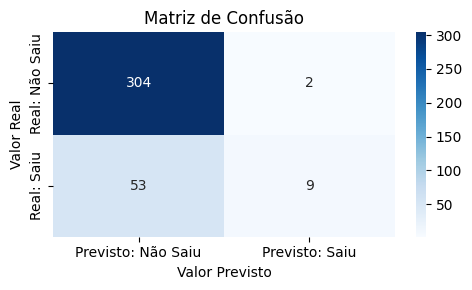


Gráfico de Importância das Variáveis no modelo:


<Figure size 640x480 with 0 Axes>

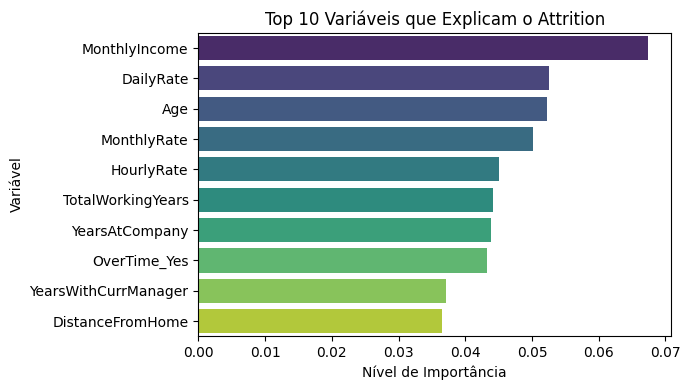

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
)
import warnings
warnings.filterwarnings('ignore')

rf_pipeline.fit(X_train, y_train) #Treinando o pipeline criado anteriormente com nossos dados

#predições
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]


print("Análise dos scores de avaliação:")


print("\nRelatório de Classificação (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=['Não Saiu (0)', 'Saiu (1)']))

#Matriz de confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Não Saiu', 'Previsto: Saiu'],
            yticklabels=['Real: Não Saiu', 'Real: Saiu'])
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.tight_layout()
plt.show()
plt.savefig('matrizconf_forest.png')



print("\nGráfico de Importância das Variáveis no modelo:")

rf_model = rf_pipeline.named_steps['classifier']
num_features = preprocessor.transformers_[0][2]
cat_features_labels = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = np.concatenate([num_features, cat_features_labels])


importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Variáveis que Explicam o Attrition')
plt.xlabel('Nível de Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig('variaveis_rforest.png')
plt.show()


### 4.3.3 - Gradient Boosting(GBM)

O Gradient Boosting (e suas implementações famosas, como XGBoost por exemplo) é frequentemente o modelo com o melhor desempenho para dados tabulares como o nosso. Ele também é um modelo de ensemble baseado em árvores, mas com uma abordagem diferente. Em vez de construir árvores independentes (como o Random Forest), ele constrói árvores em sequência. Cada nova árvore tenta corrigir os erros cometidos pela árvore anterior.


--- Avaliação do GBM ---

Classification Report (GBM):
              precision    recall  f1-score   support

      No (0)       0.89      0.97      0.93       306
     Yes (1)       0.73      0.39      0.51        62

    accuracy                           0.87       368
   macro avg       0.81      0.68      0.72       368
weighted avg       0.86      0.87      0.86       368

ROC-AUC Score (GBM): 0.8217

Matriz de Confusão (GBM):


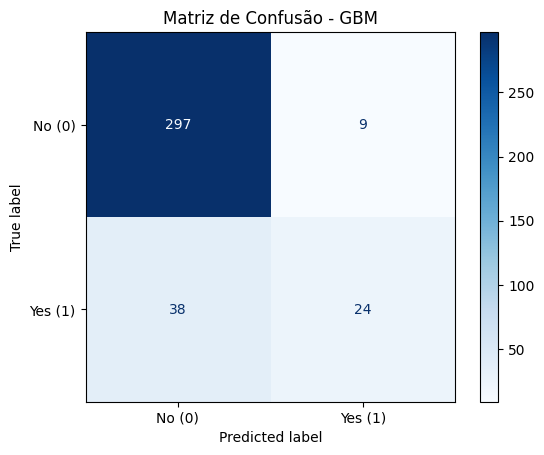

In [ ]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay)

gbm_pipeline.fit(X_train, y_train)

# Previsões e Avaliação
y_pred_gbm = gbm_pipeline.predict(X_test)
y_pred_proba_gbm = gbm_pipeline.predict_proba(X_test)[:, 1]

# Métricas
print("\n--- Avaliação do GBM ---")
print("\nClassification Report (GBM):")
print(classification_report(y_test, y_pred_gbm, target_names=['No (0)', 'Yes (1)']))

auc_score_gbm = roc_auc_score(y_test, y_pred_proba_gbm)
print(f"ROC-AUC Score (GBM): {auc_score_gbm:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão (GBM):")
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
disp_gbm = ConfusionMatrixDisplay(confusion_matrix=cm_gbm, display_labels=['No (0)', 'Yes (1)'])
disp_gbm.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - GBM")
plt.show()

Como podemos notar, O Recall para "Yes" ainda é baixo, cerca de 39%. Isso acontece porque o GBM padrão não tem nenhum tipo de balanceamento dos dados, e na nossa base temos muito mais funcionários que ficam ("Não") do que funcionários que saem ("Sim"), ou seja, um desbalanceamento. Modelos comuns, ao verem isso, aprendem que é "seguro" prever "Não" para quase todo mundo, pois isso gera uma acurácia alta. Por isso, ao tentarmos utilizar o modelo "padrão" de Gradient Boosting, obtermos um Recall muito baixo (o modelo falha em encontrar quem realmente vai sair)

### 4.3.4 - XGBoost
Uma alternativa ao nosso problema de desbalanceamento é o XGBoost, ele é uma implementação avançada e de alta performance do algoritmo Gradient Boosting (GBM), sendo um dos modelos mais eficazes para trabalhar com dados tabulares (como a nossa base, que mistura dados numéricos e categóricos). Dessa forma, escolhemos o XGBoost porque ele possui um parâmetro ideal para corrigir isso: o scale_pos_weight. Ao configurá-lo, nós "aumentamos o peso" da classe "Sim". Essencialmente, dizemos ao modelo que errar um funcionário que vai sair é muito mais grave e custoso do que errar um que vai ficar. Isso força o modelo a focar em aprender os padrões que levam ao attrition, aumentando drasticamente sua capacidade de identificar os verdadeiros casos de saída (aumentando o Recall da classe "Sim").


--- Avaliação do XGBoost ---

Classification Report (XGBoost):
              precision    recall  f1-score   support

      No (0)       0.90      0.95      0.92       306
     Yes (1)       0.66      0.47      0.55        62

    accuracy                           0.87       368
   macro avg       0.78      0.71      0.74       368
weighted avg       0.86      0.87      0.86       368

ROC-AUC Score (XGBoost): 0.8066

Matriz de Confusão (XGBoost):


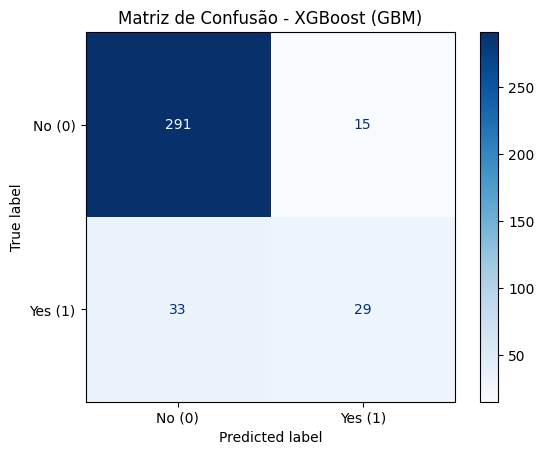

In [ ]:

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Criação do Pipeline para XGBoost (GBM)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# Treinamento
xgb_pipeline.fit(X_train, y_train)

# Previsões e Avaliação
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Métricas
print("\n--- Avaliação do XGBoost ---")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['No (0)', 'Yes (1)']))

auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC Score (XGBoost): {auc_score_xgb:.4f}")

# Matriz de Confusão
print("\nMatriz de Confusão (XGBoost):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No (0)', 'Yes (1)'])
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - XGBoost (GBM)")
plt.savefig('matrizconf_XGBoost.png')
plt.show()


Dessa forma, utilizando o XGBoost com o scale_pos_weight, conseguimos aumentar o nosso recall para a classe Yes, apenas balanceando os dados.

##4.4 Conclusões

**Metodologia de Avaliação**: F1-Score

Para avaliar e comparar o desempenho dos modelos de machine learning desenvolvidos (Regressão Logística, Random Forest, Gradient Boosting e XGBoost), a métrica de performance selecionada como principal foi o F1-Score.

A escolha do F1-Score em detrimento de métricas mais comuns, como a Acurácia, é fundamental devido à natureza do nosso conjunto de dados. Em problemas como previsão de rotatividade na empresa é comum que os dados sejam desbalanceados: a classe de interesse (ex: "Sim, saiu") é muito mais frequente que a classe majoritária (ex: "Não, ficou").

**Comparação de Desempenho e Seleção do Modelo**:

Todos os modelos foram treinados, ajustados (tuning) e avaliados utilizando o F1-Score como balizador principal nos dados de teste. Os resultados comparativos obtidos foram:

Regressão Logistica: 0,74

Random Forest: 0,85

Grandient Boost: 0,87

XGBoost: 0,87

Conforme as informações listadas, os modelos **Gradient Boost e XGBoost** alcançaram o F1-Score mais elevado, atingindo 0,87

Este resultado demonstra que ele possui o melhor equilíbrio entre a capacidade de identificar corretamente os casos positivos (Recall) sem classificar incorretamente um volume excessivo de casos negativos (Precisão). Ele superou nossa baseline (Regressão Logística) em **13 pontos percentuais**, justificando sua maior complexidade e sendo, portanto, o modelo selecionado para a implementação final do projeto.

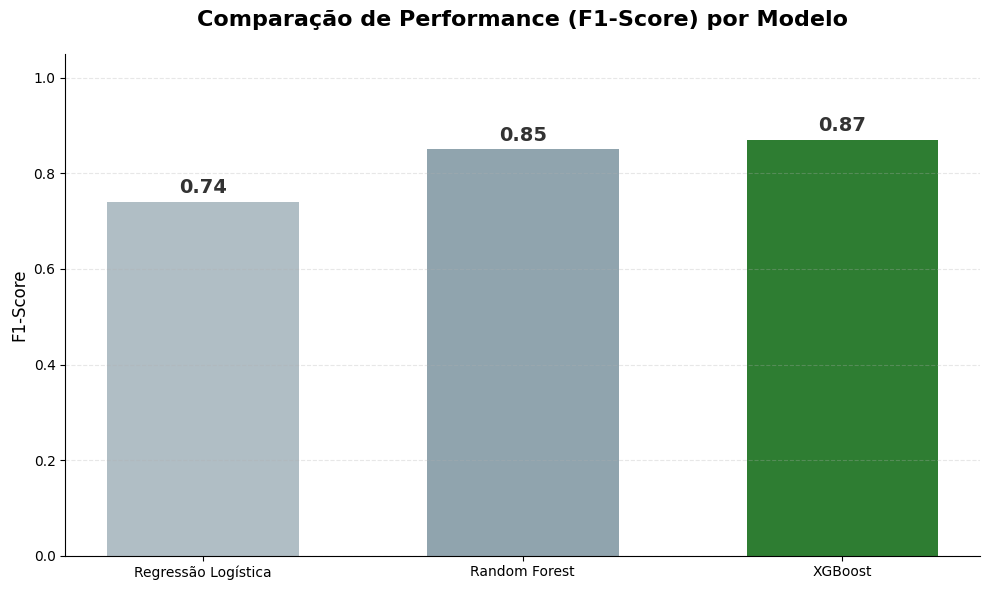

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados dos modelos e seus respectivos F1-Scores
modelos = ['Regressão Logística', 'Random Forest', 'XGBoost']
f1_scores = [0.74, 0.85, 0.87]

# Definição de cores: Cinza para os modelos de comparação, Verde para o destaque (XGBoost)
cores = ['#B0BEC5', '#90A4AE', '#2E7D32']

# Criando a figura
plt.figure(figsize=(10, 6))
bars = plt.bar(modelos, f1_scores, color=cores, width=0.6)

# Adicionando os valores exatos em cima de cada barra para facilitar a leitura
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='#333333')

# Configuração de títulos e eixos para ficar com cara de apresentação profissional
plt.title('Comparação de Performance (F1-Score) por Modelo', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.05)  # Um pouco de espaço acima da barra mais alta
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove as bordas superior e direita para um visual mais limpo (data-ink ratio)
sns.despine()

# Salva o gráfico ou exibe
plt.tight_layout()
plt.savefig('comparacao_f1_score.png', dpi=300)
plt.show()